In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler

import arviz as az

c:\Users\David\anaconda3\envs\stan\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# data = pd.read_csv('data/speed_dating_data.csv', sep=',', encoding='unicode_escape')
data = pd.read_csv('data/speed_dating_data.csv', sep=',', encoding='ISO-8859-1')
data.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='attr', ylabel='Count'>

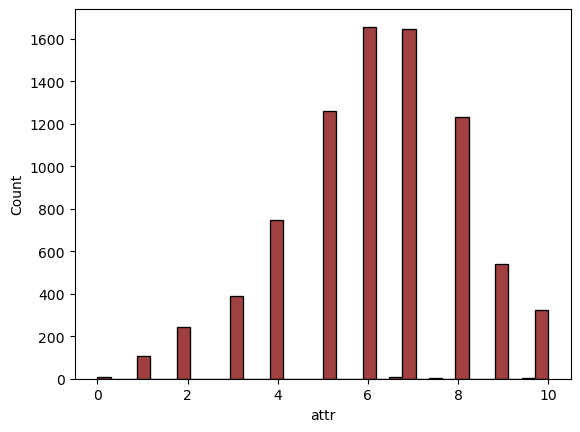

In [3]:
sns.histplot(data.attr, color='maroon', alpha=0.75)

In [4]:
data = data[['attr', 'sinc', 'shar', 'dec']].dropna()
data.info()

<class 'pandas.DataFrame'>
Index: 7267 entries, 0 to 8377
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   attr    7267 non-null   float64
 1   sinc    7267 non-null   float64
 2   shar    7267 non-null   float64
 3   dec     7267 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 283.9 KB


## Handy Function to Plot Predictions per Subject

In [5]:
scaler = StandardScaler()
cols = ['attr', 'sinc', 'shar']
data[cols] = scaler.fit_transform(data[cols])

<Axes: ylabel='Count'>

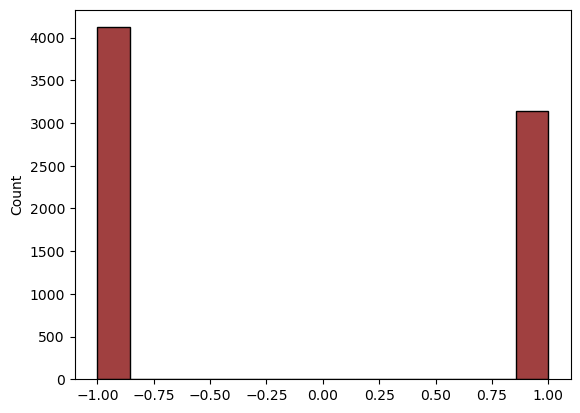

In [6]:
dec1 = np.float64(data.dec * 2 - 1)
sns.histplot(dec1, color='maroon', alpha=0.75)

In [7]:
# correlation
data[["attr", "sinc", "shar", "dec"]].corr()

,attr,sinc,shar,dec
attr,1.000000,0.401670,0.480331,0.485902
sinc,0.401670,1.000000,0.398321,0.208105
shar,0.480331,0.398321,1.000000,0.401667
dec,0.485902,0.208105,0.401667,1.000000


In [8]:
# Prepare data in Stan friendly format
data_dict = {
    'N': data.shape[0],
    'x1': data.attr,
    'x2': data.sinc,
    'x3': data.shar,
    'y': data.dec,
    'N_ex': 0,
    'x1_ex': [],
    'x2_ex': [],
    'x3_ex': [],
    'y_ex': [],
}

# Compile model
model = CmdStanModel(stan_file="models/hw4_model_new.stan")


# Sample (i.e., inverse inference)
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

19:22:55 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]





chain 1:   3%|▎         | 100/3500 [00:00<00:15, 214.19it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:01<00:17, 192.28it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:01<00:15, 206.39it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:01<00:12, 241.88it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:02<00:11, 253.78it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:02<00:10, 271.21it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:02<00:09, 298.61it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:03<00:08, 308.47it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:03<00:07, 325.38it/s, (Warmup)]





chain 1:  29%|██▊       | 1000/3500 [00:03<00:07, 315.77it/s, (Sampling)]


chain 1:  31%|███▏      | 1100/3500 [00:05<00:17, 138.14it/s, (Sampling)]


chain 1:  34%|███▍      | 1200/3500 [00:06<00:23, 98.17it/s, (Sampli

19:23:38 - cmdstanpy - INFO - CmdStan done processing.


In [9]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-3775.890000,0.020077,1.421060,1.181930,-3778.630000,-3775.550000,-3774.270000,5341.29,6691.62,33.6523,1.000700
alpha,-0.427069,0.000298,0.028620,0.028448,-0.474185,-0.427156,-0.380170,9236.72,7027.92,58.1951,1.000520
beta1,1.159350,0.000414,0.039051,0.039193,1.096330,1.158760,1.224120,8934.82,7718.83,56.2930,1.000830
beta2,-0.121185,0.000355,0.033773,0.033361,-0.176835,-0.121204,-0.065262,9101.96,6885.86,57.3460,1.000440
beta3,0.678949,0.000366,0.035087,0.034821,0.621166,0.678578,0.736848,9201.91,7749.44,57.9758,0.999995
...,...,...,...,...,...,...,...,...,...,...,...
y_hat[7263],0.069800,NaN,0.254822,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
y_hat[7264],0.144900,0.003570,0.352018,0.000000,0.000000,0.000000,1.000000,9728.81,9728.81,61.2954,1.000450
y_hat[7265],0.107000,0.003068,0.309129,0.000000,0.000000,0.000000,1.000000,10166.60,10166.60,64.0537,1.000130
y_hat[7266],0.141400,0.003535,0.348451,0.000000,0.000000,0.000000,1.000000,9735.34,9735.34,61.3366,0.999981


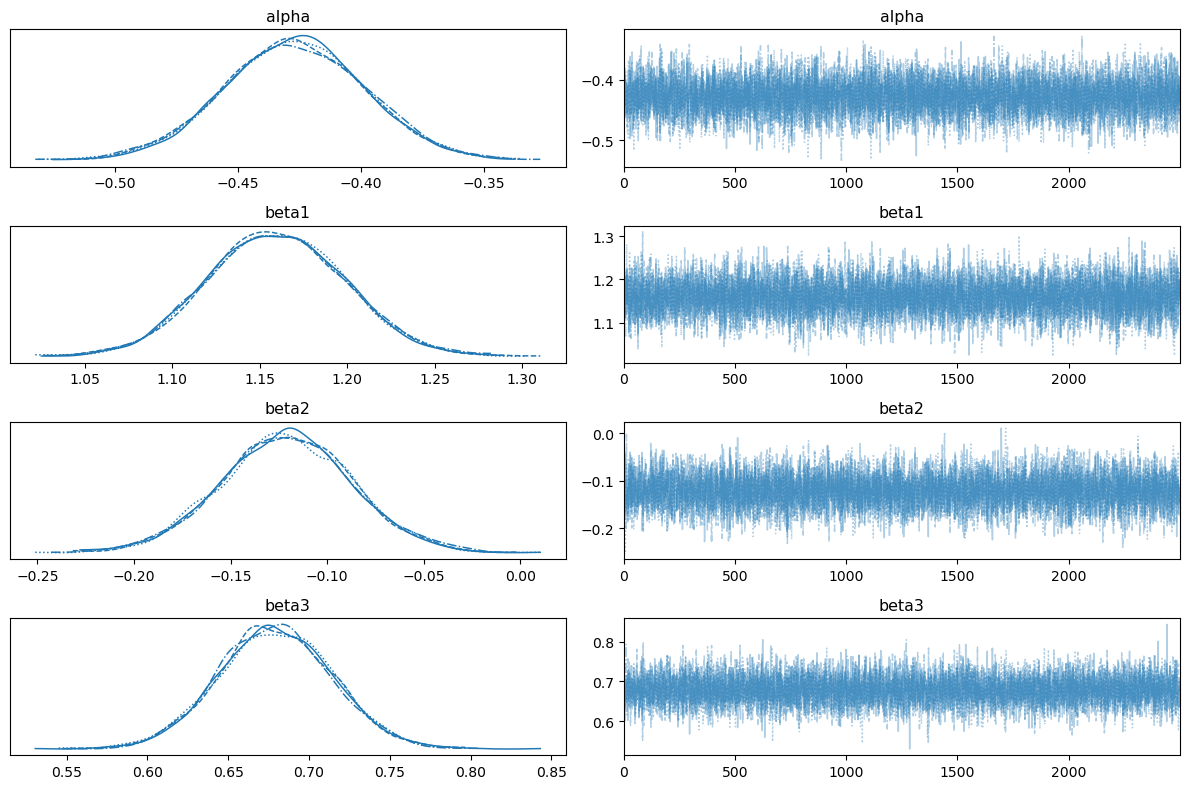

In [10]:
_ = az.plot_trace(fit, var_names=['alpha', 'beta1', 'beta2', 'beta3'])
plt.tight_layout()

In [11]:
results = fit.draws_pd()

In [12]:
results.head()

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,y_hat[7258],y_hat[7259],y_hat[7260],y_hat[7261],y_hat[7262],y_hat[7263],y_hat[7264],y_hat[7265],y_hat[7266],y_hat[7267]
0,1.0,1.0,1.0,-3774.9911,0.982464,0.699815,3.0,7.0,0.0,3776.4337,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,2.0,2.0,-3774.8159,0.968257,0.699815,2.0,7.0,0.0,3776.1024,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,3.0,3.0,-3774.1059,0.995101,0.699815,3.0,7.0,0.0,3774.9822,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,4.0,4.0,-3775.3521,0.933591,0.699815,2.0,7.0,0.0,3775.5770,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,5.0,5.0,-3775.0540,0.950363,0.699815,3.0,7.0,0.0,3777.0000,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: ylabel='Density'>

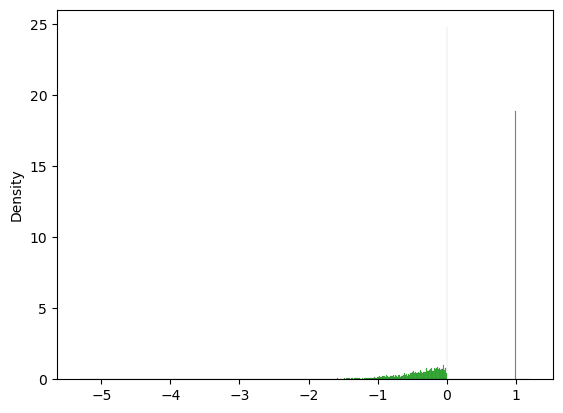

In [13]:
# Marginal check
# sns.histplot(data.shar, color='maroon', stat='density')
sns.histplot(results.iloc[:20, 10:].values.flatten(), stat='density', color='#00AA00')

In [14]:
dims = {"y": ["time"], "x1": ["time"], "preds": ["time"], "y_hat": ["time"]}
idata_kwargs = {
    "posterior_predictive": ["y_hat"],
    "log_likelihood": ["preds"],
    "dims": dims,
}
idata = az.from_cmdstanpy(
    posterior=fit, observed_data={"y": data.dec}, constant_data={"x": data.attr}, **idata_kwargs
)

In [15]:
az.summary(fit, var_names=['alpha', 'beta1', 'beta2', 'beta3'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.427,0.029,-0.479,-0.371,0.0,0.0,9237.0,7028.0,1.0
beta1,1.159,0.039,1.089,1.234,0.0,0.0,8935.0,7719.0,1.0
beta2,-0.121,0.034,-0.184,-0.056,0.0,0.0,9102.0,6886.0,1.0
beta3,0.679,0.035,0.611,0.742,0.0,0.0,9202.0,7749.0,1.0
